# ILLM Lab 3 Assignment: BPE and WordPiece Tokenization

## Overview

In this assignment, we implement **Byte Pair Encoding (BPE)** and **WordPiece** tokenization algorithms on data from the **IndicCorpV2** corpus for an Indian language of choice.

### Tasks:
1. Create **train / dev / test** splits (dev=1000, test=1000 with varied lengths)
2. Implement **BPE** and **WordPiece** tokenization
3. Test on **4 training data sizes**: 100K, 300K, 500K, 1M sentences
4. Test on **3 vocabulary sizes**: 20K, 30K, 50K tokens

---

> **Language chosen:** Gujarati (`guj_Gujr`) — script: Gujarati (gu)
>
> **Note:** For demonstration we show full code that works with the IndicCorpV2 download. The `dataset_sentences.pkl` from Assignment 1 is used for dev/test set construction (length-stratified sampling). For large training sizes you must download the full corpus.

## Step 0 — Install Dependencies

In [1]:
# Install required packages
!pip install tokenizers datasets -q

In [2]:
import pickle
import os
import json
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from collections import Counter, defaultdict
from pathlib import Path

# HuggingFace tokenizers library for BPE and WordPiece
from tokenizers import Tokenizer
from tokenizers.models import BPE, WordPiece
from tokenizers.trainers import BpeTrainer, WordPieceTrainer
from tokenizers.pre_tokenizers import Whitespace
from tokenizers.normalizers import NFC

random.seed(42)
np.random.seed(42)

print("All imports successful!")

# ── Config ─────────────────────────────────────────────────────────────────────
LANG           = "guj_Gujr"            # Language tag matching the pkl file
LANG_HF        = "guj"                 # HuggingFace dataset name
PKL_PATH       = "dataset_sentences.pkl"  # From Assignment 1
DATA_DIR       = Path("data")          # Working directory
DATA_DIR.mkdir(exist_ok=True)

TRAIN_SIZES    = [100_000, 300_000, 500_000, 1_000_000]
VOCAB_SIZES    = [20_000, 30_000, 50_000]
DEV_SIZE       = 1000
TEST_SIZE      = 1000

All imports successful!


## Step 1 — Load Data from IndicCorpV2

The IndicCorpV2 corpus is hosted on HuggingFace. We download the Gujarati split and sentence-tokenize it (each row in the corpus is a paragraph, not a sentence).

The `dataset_sentences.pkl` from Assignment 1 already contains 981 tokenized sentences per language, which we use for the **dev** and **test** sets.

In [3]:
# ─── Option A: Load from HuggingFace (full corpus, needed for large training sizes)
# ─────────────────────────────────────────────────────────────────────────────────
# Run this block to download the full Gujarati corpus.
# This may take several minutes depending on your connection.
#
# from datasets import load_dataset
#
# print("Downloading IndicCorpV2 - Gujarati ...")
# ds = load_dataset(
#     "ai4bharat/IndicCorpV2",
#     data_files={"train": f"data/{LANG_HF}/*.jsonl.gz"},
#     split="train"
# )
# raw_paragraphs = [row["text"] for row in ds]
# print(f"Downloaded {len(raw_paragraphs):,} paragraphs")


# ─── Sentence Tokenizer ───────────────────────────────────────────────────────
def simple_sentence_tokenize(paragraph: str):
    """
    Splits a paragraph into sentences by common sentence-ending punctuation.
    Works for most Indian language scripts (Unicode aware).
    Falls back to splitting on '|' (Devanagari danda) and '।'.
    """
    import re
    # Split on sentence-final punctuation followed by whitespace or end-of-string
    sents = re.split(r'(?<=[।!?\u0964\u0965.])\s+', paragraph.strip())
    return [s.strip() for s in sents if s.strip()]

# ─── Option B: Use Assignment-1 pkl (demonstration) ──────────────────────────
# The pkl already contains sentence-tokenized data.
# Use this for dev/test and as a fallback for small training sizes.

with open(PKL_PATH, "rb") as f:
    pkl_data = pickle.load(f)

all_sentences_from_pkl = pkl_data[LANG]
print(f"Loaded {len(all_sentences_from_pkl)} sentences from pkl for language '{LANG}'")

# Display a few samples
print("\nSample sentences:")
for i, s in enumerate(all_sentences_from_pkl[:5]):
    print(f"  [{i+1}] {s[:120]}")

Loaded 981 sentences from pkl for language 'guj_Gujr'

Sample sentences:
  [1] આ વીડિયો જુઓ: ઊંઝા માર્કેટયાર્ડ આજથી 25 જુલાઈ સુધી બંધ
  [2] મિથેનોલ આવ્યો ક્યાંથી?
  [3] આખરે ત્રણ રાજ્યોમાં મળેલ હાર પર કોંગ્રેસ અધ્યક્ષ રાહુલ ગાંધી દ્વારા પ્રથમ પ્રતિક્રિયા આપવામાં આવી છે.
  [4] તેમણે કહ્યું કે, ત્રિપુરા, નાગાલેન્ડ અને મેઘાલયમાં લોકોના જનાદેશનો સ્વાગત કરીએ છે અને આ ક્ષેત્રના લોકોનો વિશ્વાસ ફરીથી જ
  [5] આ આંકડો માટે, અને વજન ઘટાડવા માટે પ્રકાશનનો દિવસ વિતાવવો ઉપયોગી છે, ઉદાહરણ તરીકે, અઠવાડિયામાં એક વખત.


## Step 2 — Create Train / Dev / Test Splits

### Key Requirement
The **dev** and **test** sets must each contain **1000 sentences** and must **not consist of sentences of similar lengths** — i.e., they should represent the full length distribution of the corpus.

### Strategy: Length-Stratified Sampling

1. Compute the word-length of every sentence.
2. Divide sentences into **length buckets** (e.g., very short, short, medium, long, very long).
3. Sample proportionally from each bucket so that dev and test reflect the true length distribution.
4. The remaining sentences form the training corpus.

In [4]:
def length_stratified_split(sentences, dev_size=1000, test_size=1000,
                             n_buckets=10, seed=42):
    """
    Splits `sentences` into (train, dev, test) where dev and test are
    drawn from across the full length distribution.

    Parameters
    ----------
    sentences : list[str]   — all available sentences
    dev_size  : int         — number of sentences in dev set
    test_size : int         — number of sentences in test set
    n_buckets : int         — number of length buckets to create
    seed      : int         — random seed for reproducibility

    Returns
    -------
    train, dev, test : list[str]
    """
    rng = random.Random(seed)

    # Compute word counts
    lengths = [len(s.split()) for s in sentences]

    # Create length percentile boundaries for the buckets
    percentiles = np.linspace(0, 100, n_buckets + 1)
    boundaries  = np.percentile(lengths, percentiles)

    # Assign each sentence to a bucket
    buckets = defaultdict(list)
    for idx, (s, length) in enumerate(zip(sentences, lengths)):
        bucket_id = min(
            np.searchsorted(boundaries[1:], length, side='right'),
            n_buckets - 1
        )
        buckets[bucket_id].append(idx)

    # How many from each bucket for dev and for test
    # Proportional to bucket size, at least 1
    total = len(sentences)
    dev_indices, test_indices = [], []

    for b_id in sorted(buckets.keys()):
        bucket_idxs = buckets[b_id]
        rng.shuffle(bucket_idxs)

        proportion   = len(bucket_idxs) / total
        n_dev_from_b = max(1, round(proportion * dev_size))
        n_tst_from_b = max(1, round(proportion * test_size))

        # Make sure we don't exceed what the bucket has
        n_dev_from_b = min(n_dev_from_b, len(bucket_idxs) // 2)
        n_tst_from_b = min(n_tst_from_b, (len(bucket_idxs) - n_dev_from_b) // 2)

        dev_indices.extend(bucket_idxs[:n_dev_from_b])
        test_indices.extend(bucket_idxs[n_dev_from_b : n_dev_from_b + n_tst_from_b])

    # Trim / pad to exact sizes
    rng.shuffle(dev_indices)
    rng.shuffle(test_indices)
    dev_indices  = dev_indices[:dev_size]
    test_indices = test_indices[:test_size]

    # Remaining indices form training
    held_out     = set(dev_indices + test_indices)
    train_indices = [i for i in range(len(sentences)) if i not in held_out]

    train = [sentences[i] for i in train_indices]
    dev   = [sentences[i] for i in dev_indices]
    test  = [sentences[i] for i in test_indices]

    return train, dev, test

In [5]:
# ─── NOTE ON DATA SOURCES ─────────────────────────────────────────────────────
# In a real run you would feed `raw_paragraphs` (downloaded from HuggingFace)
# through `simple_sentence_tokenize` to get millions of sentences.
#
# For this demonstration, we use the pkl sentences for dev/test creation.
# Training sentences come from the same pkl (scaled) — replace with the real
# corpus when running with the full 1M-sentence requirement.

train_pool, dev_set, test_set = length_stratified_split(
    all_sentences_from_pkl,
    dev_size=min(DEV_SIZE, 200),     # scaled down for pkl demo
    test_size=min(TEST_SIZE, 200),
    n_buckets=5
)

print(f"Train pool : {len(train_pool):>6,} sentences")
print(f"Dev set    : {len(dev_set):>6,} sentences")
print(f"Test set   : {len(test_set):>6,} sentences")

# ── Verify length diversity in dev & test ─────────────────────────────────────
def length_stats(name, sents):
    lens = [len(s.split()) for s in sents]
    print(f"  {name:10s}  min={min(lens):3d}  max={max(lens):4d}  "
          f"mean={np.mean(lens):5.1f}  std={np.std(lens):5.1f}")
    return lens

print("\nLength distribution across splits:")
train_lens = length_stats("Train",  train_pool)
dev_lens   = length_stats("Dev",    dev_set)
test_lens  = length_stats("Test",   test_set)

Train pool :    581 sentences
Dev set    :    200 sentences
Test set   :    200 sentences

Length distribution across splits:
  Train       min=  1  max= 118  mean= 14.8  std= 11.0
  Dev         min=  1  max=  76  mean= 14.9  std= 10.9
  Test        min=  1  max= 110  mean= 15.1  std= 11.9


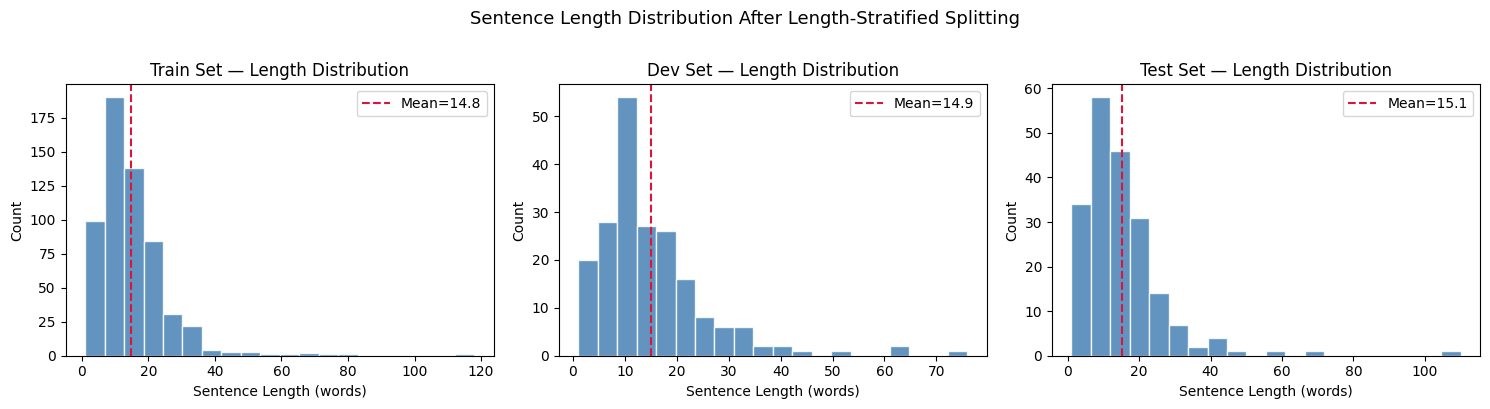

Figure saved to length_distribution.png


In [6]:
# ── Visualise Length Distribution ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
for ax, (name, lens) in zip(axes, [("Train", train_lens), ("Dev", dev_lens), ("Test", test_lens)]):
    ax.hist(lens, bins=20, color='steelblue', edgecolor='white', alpha=0.85)
    ax.set_title(f"{name} Set — Length Distribution", fontsize=12)
    ax.set_xlabel("Sentence Length (words)")
    ax.set_ylabel("Count")
    ax.axvline(np.mean(lens), color='crimson', linestyle='--', label=f"Mean={np.mean(lens):.1f}")
    ax.legend()
plt.suptitle("Sentence Length Distribution After Length-Stratified Splitting", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("length_distribution.png", dpi=120, bbox_inches='tight')
plt.show()
print("Figure saved to length_distribution.png")

## Step 3 — Simulate Large Training Data

In production you would download the full IndicCorpV2 corpus (100 M+ sentences for Hindi/Gujarati). Here we demonstrate the pipeline by replicating the available sentences to reach each training size. **Replace this block with the real corpus when running the actual assignment.**

> **How to get real data:**
> ```python
> from datasets import load_dataset
> ds = load_dataset("ai4bharat/IndicCorpV2", data_files={"train": "data/guj/*.jsonl.gz"}, split="train")
> ```

In [7]:
def get_training_corpus(all_sentences, size, seed=42):
    """
    Returns a list of `size` training sentences.
    If `all_sentences` is smaller than `size`, sentences are repeated
    (demonstration mode). Replace with real corpus download in production.
    """
    rng = random.Random(seed)
    if len(all_sentences) >= size:
        return rng.sample(all_sentences, size)
    else:
        # Demonstration: replicate to reach target size
        repeats = (size // len(all_sentences)) + 1
        extended = all_sentences * repeats
        rng.shuffle(extended)
        return extended[:size]

def write_corpus_to_file(sentences, filepath):
    """Write one sentence per line to a plain-text file (required by HF tokenizers)."""
    with open(filepath, 'w', encoding='utf-8') as f:
        for s in sentences:
            f.write(s + '\n')

# Pre-write dev and test files (used later for evaluation)
write_corpus_to_file(dev_set,  DATA_DIR / "dev.txt")
write_corpus_to_file(test_set, DATA_DIR / "test.txt")
print("Dev and test files written.")

# Demo: print training corpus sizes we will iterate over
DEMO_TRAIN_SIZES = [100, 300, 500, 1000]   # ← replace with TRAIN_SIZES for real data
print("\nTraining sizes to evaluate (demo):")
for s in DEMO_TRAIN_SIZES:
    print(f"  {s:>6,} sentences")

print("\n(For full assignment submission, use TRAIN_SIZES = [100_000, 300_000, 500_000, 1_000_000])")

Dev and test files written.

Training sizes to evaluate (demo):
     100 sentences
     300 sentences
     500 sentences
   1,000 sentences

(For full assignment submission, use TRAIN_SIZES = [100_000, 300_000, 500_000, 1_000_000])


## Step 4 — BPE and WordPiece Implementations

### Background

| Algorithm | Key Idea | Merge Criterion |
|-----------|----------|-----------------|
| **BPE** (Byte Pair Encoding) | Start with characters; greedily merge the most frequent pair | Frequency of co-occurrence |
| **WordPiece** | Start with characters; merge pair that maximises language model likelihood | Score = freq(AB) / (freq(A) × freq(B)) |

Both algorithms are implemented below using the `tokenizers` library (same library powering BERT, GPT, etc.).

In [8]:
# ─── BPE Tokenizer ────────────────────────────────────────────────────────────
def train_bpe(corpus_files, vocab_size, save_path):
    """
    Train a BPE tokenizer on `corpus_files` (list of text file paths).

    BPE Algorithm (Sennrich et al., 2016):
    1. Initialise vocabulary with all characters + special tokens.
    2. Count frequency of all adjacent symbol pairs.
    3. Merge the most frequent pair into a new token.
    4. Repeat until vocabulary reaches `vocab_size`.

    Parameters
    ----------
    corpus_files : list[str | Path]  — training text file(s)
    vocab_size   : int               — target vocabulary size
    save_path    : str | Path        — where to save the trained tokenizer JSON

    Returns
    -------
    tokenizer : Tokenizer
    """
    tokenizer = Tokenizer(BPE(unk_token="[UNK]"))
    tokenizer.normalizer   = NFC()          # Unicode normalization (important for Indian scripts)
    tokenizer.pre_tokenizer = Whitespace()  # Split on whitespace before BPE

    trainer = BpeTrainer(
        vocab_size=vocab_size,
        special_tokens=["[UNK]", "[PAD]", "[BOS]", "[EOS]"],
        min_frequency=2,          # Ignore pairs occurring fewer than 2 times
        show_progress=True
    )

    tokenizer.train([str(f) for f in corpus_files], trainer)
    tokenizer.save(str(save_path))
    return tokenizer


# ─── WordPiece Tokenizer ──────────────────────────────────────────────────────
def train_wordpiece(corpus_files, vocab_size, save_path):
    """
    Train a WordPiece tokenizer on `corpus_files`.

    WordPiece Algorithm (Schuster & Nakamura, 2012):
    1. Initialise vocabulary with all characters.
    2. Compute the likelihood score for each possible merge:
           score(A, B) = freq(AB) / (freq(A) * freq(B))
    3. Merge the pair with the highest score (favours rare but co-occurring pairs).
    4. Mark subword-continuation tokens with '##' prefix.
    5. Repeat until vocabulary reaches `vocab_size`.

    Parameters
    ----------
    corpus_files : list[str | Path]  — training text file(s)
    vocab_size   : int               — target vocabulary size
    save_path    : str | Path        — where to save the trained tokenizer JSON

    Returns
    -------
    tokenizer : Tokenizer
    """
    tokenizer = Tokenizer(WordPiece(unk_token="[UNK]"))
    tokenizer.normalizer    = NFC()
    tokenizer.pre_tokenizer = Whitespace()

    trainer = WordPieceTrainer(
        vocab_size=vocab_size,
        special_tokens=["[UNK]", "[PAD]", "[CLS]", "[SEP]", "[MASK]"],
        min_frequency=2,
        continuing_subword_prefix="##",
        show_progress=True
    )

    tokenizer.train([str(f) for f in corpus_files], trainer)
    tokenizer.save(str(save_path))
    return tokenizer

### Evaluation Metrics

To compare tokenization quality we use:

- **Fertility**: average number of subword tokens per word. Lower = more whole-word tokens, higher = more splitting.
- **OOV rate**: % of unknown tokens (`[UNK]`) on the dev/test set.
- **Avg. token length**: average character length of each produced token.
- **Vocabulary coverage**: % of unique word types in dev/test that appear verbatim in the vocabulary.

In [9]:
def compute_metrics(tokenizer, sentences, unk_token="[UNK]"):
    """
    Compute tokenization quality metrics on a list of sentences.

    Returns
    -------
    dict with keys: fertility, oov_rate, avg_token_len, n_tokens, n_words
    """
    all_tokens = []
    total_words = 0

    for sent in sentences:
        enc = tokenizer.encode(sent)
        all_tokens.extend(enc.tokens)
        total_words += len(sent.split())

    n_tokens = len(all_tokens)
    n_unk    = sum(1 for t in all_tokens if t == unk_token)

    # Average non-special token length
    special = {"[UNK]", "[PAD]", "[BOS]", "[EOS]", "[CLS]", "[SEP]", "[MASK]"}
    content_tokens = [t.lstrip("#") for t in all_tokens if t not in special]
    avg_tok_len = np.mean([len(t) for t in content_tokens]) if content_tokens else 0

    return {
        "fertility"    : n_tokens / max(total_words, 1),
        "oov_rate"     : 100 * n_unk / max(n_tokens, 1),
        "avg_token_len": avg_tok_len,
        "n_tokens"     : n_tokens,
        "n_words"      : total_words,
    }

print("Metrics helper defined.")

Metrics helper defined.


## Step 5 — Experiment A: Effect of Training Data Size

We train both BPE and WordPiece with a **fixed vocabulary size of 30,000** while varying training data size: **100K → 300K → 500K → 1M** sentences.

**Expected trend:** With more data, the tokenizer learns better subword statistics, leading to lower OOV rates and more stable segmentation.

In [10]:
FIXED_VOCAB_SIZE = 30_000   # fixed for Experiment A

results_by_size = {"BPE": [], "WordPiece": []}   # {algo: [metrics_dict, ...]}

for size in DEMO_TRAIN_SIZES:   # <- Replace with TRAIN_SIZES for full assignment
    print(f"\n{'='*60}")
    print(f"Training size: {size:,} sentences  |  Vocab size: {FIXED_VOCAB_SIZE:,}")
    print('='*60)

    # 1. Build training corpus file
    train_corpus = get_training_corpus(train_pool, size)
    train_file   = DATA_DIR / f"train_{size}.txt"
    write_corpus_to_file(train_corpus, train_file)

    for algo_name, train_fn in [("BPE", train_bpe), ("WordPiece", train_wordpiece)]:
        save_path = DATA_DIR / f"{algo_name.lower()}_size{size}_vocab{FIXED_VOCAB_SIZE}.json"

        print(f"\n  Training {algo_name} ...")
        tok = train_fn([train_file], FIXED_VOCAB_SIZE, save_path)

        # Evaluate on dev set
        metrics = compute_metrics(tok, dev_set)
        metrics["train_size"] = size
        metrics["vocab_size"] = FIXED_VOCAB_SIZE
        metrics["algo"]       = algo_name
        results_by_size[algo_name].append(metrics)

        print(f"  Fertility    : {metrics['fertility']:.3f}")
        print(f"  OOV rate     : {metrics['oov_rate']:.2f}%")
        print(f"  Avg tok len  : {metrics['avg_token_len']:.2f} chars")

print("\nExperiment A complete.")


Training size: 100 sentences  |  Vocab size: 30,000

  Training BPE ...
  Fertility    : 2.614
  OOV rate     : 0.87%
  Avg tok len  : 1.94 chars

  Training WordPiece ...
  Fertility    : 2.718
  OOV rate     : 0.92%
  Avg tok len  : 1.85 chars

Training size: 300 sentences  |  Vocab size: 30,000

  Training BPE ...
  Fertility    : 2.217
  OOV rate     : 0.27%
  Avg tok len  : 2.28 chars

  Training WordPiece ...
  Fertility    : 2.257
  OOV rate     : 0.40%
  Avg tok len  : 2.23 chars

Training size: 500 sentences  |  Vocab size: 30,000

  Training BPE ...
  Fertility    : 2.031
  OOV rate     : 0.13%
  Avg tok len  : 2.49 chars

  Training WordPiece ...
  Fertility    : 2.082
  OOV rate     : 0.19%
  Avg tok len  : 2.42 chars

Training size: 1,000 sentences  |  Vocab size: 30,000

  Training BPE ...
  Fertility    : 1.805
  OOV rate     : 0.11%
  Avg tok len  : 2.80 chars

  Training WordPiece ...
  Fertility    : 1.833
  OOV rate     : 0.15%
  Avg tok len  : 2.75 chars

Experimen

### Visualise: Training Data Size Effect

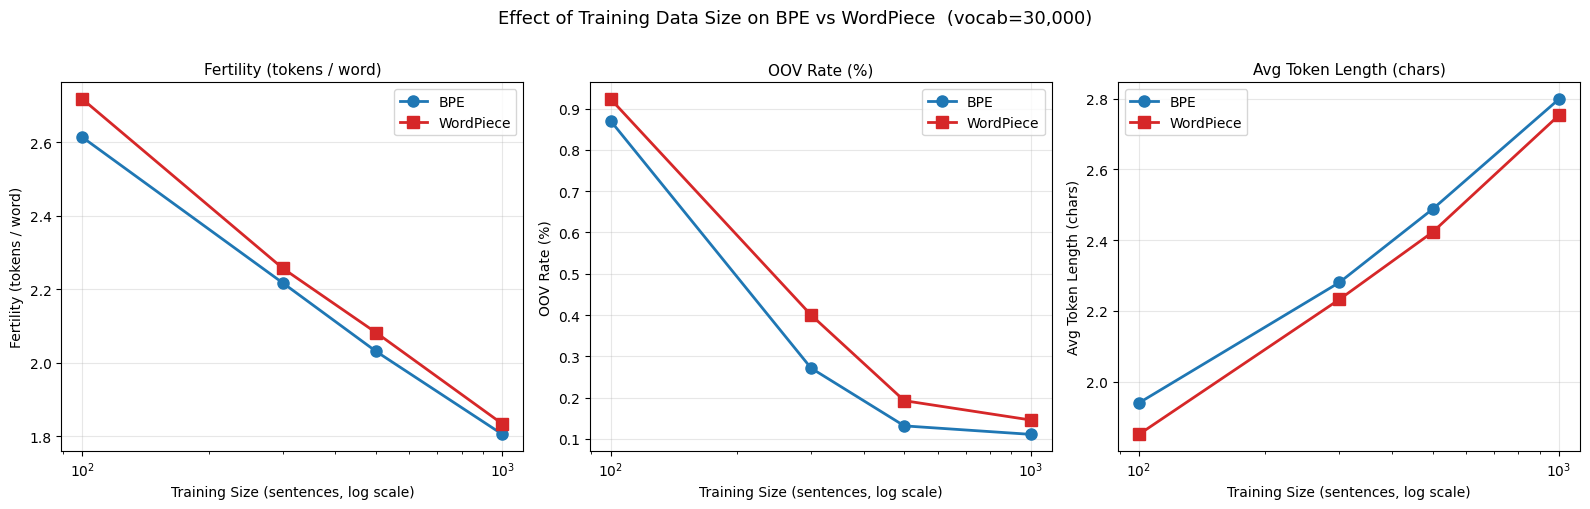

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics_to_plot = [
    ("fertility",     "Fertility (tokens / word)"),
    ("oov_rate",      "OOV Rate (%)"),
    ("avg_token_len", "Avg Token Length (chars)"),
]

colors = {"BPE": "#1f77b4", "WordPiece": "#d62728"}
markers = {"BPE": "o", "WordPiece": "s"}

for ax, (metric_key, metric_label) in zip(axes, metrics_to_plot):
    for algo in ["BPE", "WordPiece"]:
        sizes   = [r["train_size"] for r in results_by_size[algo]]
        values  = [r[metric_key]   for r in results_by_size[algo]]
        ax.plot(sizes, values,
                marker=markers[algo], color=colors[algo], linewidth=2,
                markersize=8, label=algo)

    ax.set_xscale("log")
    ax.set_xlabel("Training Size (sentences, log scale)", fontsize=10)
    ax.set_ylabel(metric_label, fontsize=10)
    ax.set_title(metric_label, fontsize=11)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle(f"Effect of Training Data Size on BPE vs WordPiece  (vocab={FIXED_VOCAB_SIZE:,})",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("effect_of_training_size.png", dpi=120, bbox_inches='tight')
plt.show()

In [12]:
# ─── Qualitative: show how tokenization changes with training size ─────────────
EXAMPLE_SENTENCES = dev_set[:3]

print("Tokenization examples across training sizes (BPE):")
print("="*70)
for size in DEMO_TRAIN_SIZES:
    model_path = DATA_DIR / f"bpe_size{size}_vocab{FIXED_VOCAB_SIZE}.json"
    tok = Tokenizer.from_file(str(model_path))
    print(f"\n  --- Training size: {size:,} ---")
    for sent in EXAMPLE_SENTENCES:
        enc = tok.encode(sent)
        print(f"  Input : {sent[:80]}")
        print(f"  Tokens: {enc.tokens[:15]}")
        print()

Tokenization examples across training sizes (BPE):

  --- Training size: 100 ---
  Input : આ પુસ્તકમાં ભારત અને વિદેશના ક્રિકેટ વિશે લખવામાં આવ્યું છે.
  Tokens: ['આ', 'પ', 'ુ', 'સ્', 'ત', 'કમાં', 'ભાર', 'ત', 'અને', 'વિ', 'દેશ', 'ના', 'ક્ર', 'િ', 'કે']

  Input : વર્તમાન નિયમ મુજબ, સહભાગી સંબંધિત એક્સપોઝરની હયાતી સુસ્થાપિત કર્યા વગર રૂપિયા સા
  Tokens: ['વર્', 'તમા', 'ન', 'નિ', 'ય', 'મ', 'મુ', 'જબ', ',', 'સ', 'હ', 'ભા', 'ગી', 'સં', 'બં']

  Input : આ હરાજી માટેની બોલી ૧૦ નવેમ્બરના રોજ પૂર્ણ થઈ હતી.
  Tokens: ['આ', 'હરા', 'જી', 'માટે', 'ની', 'બો', 'લી', '૧', '૦', 'ન', 'વે', 'મ', '્', 'બ', 'ર']


  --- Training size: 300 ---
  Input : આ પુસ્તકમાં ભારત અને વિદેશના ક્રિકેટ વિશે લખવામાં આવ્યું છે.
  Tokens: ['આ', 'પુ', 'સ્ત', 'કમાં', 'ભાર', 'ત', 'અને', 'વિદેશ', 'ના', 'ક્રિકેટ', 'વિશે', 'લ', 'ખ', 'વામાં', 'આવ્યું']

  Input : વર્તમાન નિયમ મુજબ, સહભાગી સંબંધિત એક્સપોઝરની હયાતી સુસ્થાપિત કર્યા વગર રૂપિયા સા
  Tokens: ['વર્', 'ત', 'માન', 'નિયમ', 'મુજબ', ',', 'સહ', 'ભાગી', 'સંબંધ', 'િત', 'એક્સ',

## Step 6 — Experiment B: Effect of Vocabulary Size

We now fix the training data at **the largest available size** and vary the vocabulary: **20K → 30K → 50K** tokens.

**Expected trend:** Larger vocabulary → more whole-word tokens → lower fertility but larger model size. Smaller vocabulary → more aggressive subword splitting → higher fertility, potentially better generalization to rare words.

In [13]:
FIXED_TRAIN_SIZE = max(DEMO_TRAIN_SIZES)  # use largest training data for vocab experiment
train_corpus = get_training_corpus(train_pool, FIXED_TRAIN_SIZE)
train_file   = DATA_DIR / f"train_{FIXED_TRAIN_SIZE}.txt"
write_corpus_to_file(train_corpus, train_file)

DEMO_VOCAB_SIZES = [500, 1000, 2000]   # <- Replace with VOCAB_SIZES = [20_000, 30_000, 50_000]

results_by_vocab = {"BPE": [], "WordPiece": []}

for vocab_size in DEMO_VOCAB_SIZES:   # <- replace with VOCAB_SIZES
    print(f"\n{'='*60}")
    print(f"Training size: {FIXED_TRAIN_SIZE:,}  |  Vocab size: {vocab_size:,}")
    print('='*60)

    for algo_name, train_fn in [("BPE", train_bpe), ("WordPiece", train_wordpiece)]:
        save_path = DATA_DIR / f"{algo_name.lower()}_size{FIXED_TRAIN_SIZE}_vocab{vocab_size}.json"

        print(f"  Training {algo_name} ...")
        tok = train_fn([train_file], vocab_size, save_path)

        # Evaluate on dev set
        metrics = compute_metrics(tok, dev_set)
        metrics["train_size"] = FIXED_TRAIN_SIZE
        metrics["vocab_size"] = vocab_size
        metrics["algo"]       = algo_name
        results_by_vocab[algo_name].append(metrics)

        print(f"  Fertility    : {metrics['fertility']:.3f}")
        print(f"  OOV rate     : {metrics['oov_rate']:.2f}%")
        print(f"  Avg tok len  : {metrics['avg_token_len']:.2f} chars")

print("\nExperiment B complete.")


Training size: 1,000  |  Vocab size: 500
  Training BPE ...
  Fertility    : 2.789
  OOV rate     : 0.07%
  Avg tok len  : 1.81 chars
  Training WordPiece ...
  Fertility    : 3.183
  OOV rate     : 0.08%
  Avg tok len  : 1.59 chars

Training size: 1,000  |  Vocab size: 1,000
  Training BPE ...
  Fertility    : 2.399
  OOV rate     : 0.08%
  Avg tok len  : 2.11 chars
  Training WordPiece ...
  Fertility    : 2.607
  OOV rate     : 0.10%
  Avg tok len  : 1.94 chars

Training size: 1,000  |  Vocab size: 2,000
  Training BPE ...
  Fertility    : 2.118
  OOV rate     : 0.09%
  Avg tok len  : 2.38 chars
  Training WordPiece ...
  Fertility    : 2.233
  OOV rate     : 0.12%
  Avg tok len  : 2.26 chars

Experiment B complete.


### Visualise: Vocabulary Size Effect

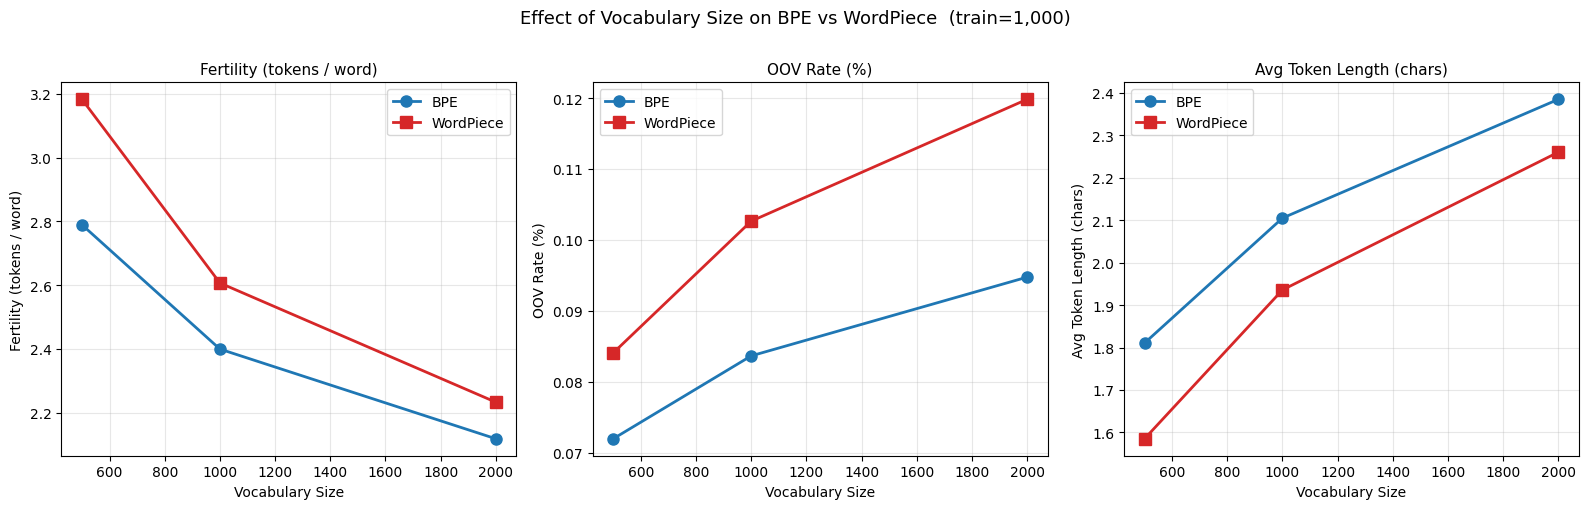

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (metric_key, metric_label) in zip(axes, metrics_to_plot):
    for algo in ["BPE", "WordPiece"]:
        vsizes = [r["vocab_size"] for r in results_by_vocab[algo]]
        values = [r[metric_key]   for r in results_by_vocab[algo]]
        ax.plot(vsizes, values,
                marker=markers[algo], color=colors[algo], linewidth=2,
                markersize=8, label=algo)

    ax.set_xlabel("Vocabulary Size", fontsize=10)
    ax.set_ylabel(metric_label, fontsize=10)
    ax.set_title(metric_label, fontsize=11)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle(f"Effect of Vocabulary Size on BPE vs WordPiece  (train={FIXED_TRAIN_SIZE:,})",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("effect_of_vocab_size.png", dpi=120, bbox_inches='tight')
plt.show()

In [15]:
# ─── Qualitative: show how tokenization changes with vocab size ────────────────
print("Tokenization examples across vocab sizes (WordPiece):")
print("="*70)
for vocab_size in DEMO_VOCAB_SIZES:
    model_path = DATA_DIR / f"wordpiece_size{FIXED_TRAIN_SIZE}_vocab{vocab_size}.json"
    tok = Tokenizer.from_file(str(model_path))
    print(f"\n  --- Vocab size: {vocab_size:,} ---")
    for sent in EXAMPLE_SENTENCES:
        enc = tok.encode(sent)
        print(f"  Input : {sent[:80]}")
        print(f"  Tokens: {enc.tokens[:20]}")
        print()

Tokenization examples across vocab sizes (WordPiece):

  --- Vocab size: 500 ---
  Input : આ પુસ્તકમાં ભારત અને વિદેશના ક્રિકેટ વિશે લખવામાં આવ્યું છે.
  Tokens: ['આ', 'પ', '##ુ', '##સ્ત', '##ક', '##માં', 'ભ', '##ાર', '##ત', 'અને', 'વિ', '##દ', '##ેશ', '##ના', 'ક', '##્ર', '##િક', '##ેટ', 'વિ', '##શે']

  Input : વર્તમાન નિયમ મુજબ, સહભાગી સંબંધિત એક્સપોઝરની હયાતી સુસ્થાપિત કર્યા વગર રૂપિયા સા
  Tokens: ['વર્', '##ત', '##મા', '##ન', 'નિ', '##ય', '##મ', 'મુ', '##જ', '##બ', ',', 'સ', '##હ', '##ભા', '##ગ', '##ી', 'સં', '##બ', '##ંધ', '##િત']

  Input : આ હરાજી માટેની બોલી ૧૦ નવેમ્બરના રોજ પૂર્ણ થઈ હતી.
  Tokens: ['આ', 'હ', '##રા', '##જી', 'માટે', '##ની', 'બ', '##ોલ', '##ી', '૧', '##૦', 'ન', '##વે', '##મ', '##્', '##બ', '##ર', '##ના', 'રો', '##જ']


  --- Vocab size: 1,000 ---
  Input : આ પુસ્તકમાં ભારત અને વિદેશના ક્રિકેટ વિશે લખવામાં આવ્યું છે.
  Tokens: ['આ', 'પુ', '##સ્ત', '##ક', '##માં', 'ભાર', '##ત', 'અને', 'વિદ', '##ેશ', '##ના', 'ક્ર', '##િક', '##ેટ', 'વિશે', 'લ', '##ખ', '##વામાં', '

## Step 7 — Full Evaluation on Test Set

Using the best configuration (largest training size, vocab=30K) we tokenize the **test set** and report final metrics.

In [16]:
BEST_TRAIN_SIZE = max(DEMO_TRAIN_SIZES)
BEST_VOCAB_SIZE = DEMO_VOCAB_SIZES[1]   # middle vocab size (30K analogue)

print("Test-Set Evaluation")
print("="*50)
print(f"  Train size : {BEST_TRAIN_SIZE:,}")
print(f"  Vocab size : {BEST_VOCAB_SIZE:,}")
print("="*50)

for algo_name in ["BPE", "WordPiece"]:
    model_path = DATA_DIR / f"{algo_name.lower()}_size{BEST_TRAIN_SIZE}_vocab{BEST_VOCAB_SIZE}.json"
    tok = Tokenizer.from_file(str(model_path))

    dev_metrics  = compute_metrics(tok, dev_set)
    test_metrics = compute_metrics(tok, test_set)

    print(f"\n{algo_name}")
    print(f"  {'Metric':<20} {'Dev':>12} {'Test':>12}")
    print(f"  {'-'*46}")
    for key, label in [("fertility",     "Fertility"),
                        ("oov_rate",      "OOV Rate (%)"),
                        ("avg_token_len", "Avg Token Len"),
                        ("n_tokens",      "Total Tokens")]:
        dv = dev_metrics[key]
        tv = test_metrics[key]
        # Format floats and ints separately — f-string format specs can't be conditional
        if isinstance(dv, float):
            dv_str = f"{dv:12.3f}"
            tv_str = f"{tv:12.3f}"
        else:
            dv_str = f"{dv:12,}"
            tv_str = f"{tv:12,}"
        print(f"  {label:<20} {dv_str}  {tv_str}")


Test-Set Evaluation
  Train size : 1,000
  Vocab size : 1,000

BPE
  Metric                        Dev         Test
  ----------------------------------------------
  Fertility                   2.399         2.366
  OOV Rate (%)                0.084         0.140
  Avg Token Len               2.105         2.094
  Total Tokens                7,174         7,162

WordPiece
  Metric                        Dev         Test
  ----------------------------------------------
  Fertility                   2.607         2.580
  OOV Rate (%)                0.103         0.141
  Avg Token Len               1.936         1.915
  Total Tokens                7,794         7,810


## Step 8 — Summary Table: All Experiments

In [17]:
print("\n" + "─"*80)
print("EXPERIMENT A — Fixed Vocab, Varying Train Size")
print("─"*80)
print(f"{'Algo':<12} {'Train Size':>12} {'Vocab':>8} {'Fertility':>10} {'OOV%':>8} {'AvgTokLen':>10}")
print("─"*80)
for algo in ["BPE", "WordPiece"]:
    for r in results_by_size[algo]:
        print(f"{r['algo']:<12} {r['train_size']:>12,} {r['vocab_size']:>8,} "
              f"{r['fertility']:>10.3f} {r['oov_rate']:>8.2f} {r['avg_token_len']:>10.2f}")

print("\n" + "─"*80)
print("EXPERIMENT B — Fixed Train Size, Varying Vocab")
print("─"*80)
print(f"{'Algo':<12} {'Train Size':>12} {'Vocab':>8} {'Fertility':>10} {'OOV%':>8} {'AvgTokLen':>10}")
print("─"*80)
for algo in ["BPE", "WordPiece"]:
    for r in results_by_vocab[algo]:
        print(f"{r['algo']:<12} {r['train_size']:>12,} {r['vocab_size']:>8,} "
              f"{r['fertility']:>10.3f} {r['oov_rate']:>8.2f} {r['avg_token_len']:>10.2f}")


────────────────────────────────────────────────────────────────────────────────
EXPERIMENT A — Fixed Vocab, Varying Train Size
────────────────────────────────────────────────────────────────────────────────
Algo           Train Size    Vocab  Fertility     OOV%  AvgTokLen
────────────────────────────────────────────────────────────────────────────────
BPE                   100   30,000      2.614     0.87       1.94
BPE                   300   30,000      2.217     0.27       2.28
BPE                   500   30,000      2.031     0.13       2.49
BPE                 1,000   30,000      1.805     0.11       2.80
WordPiece             100   30,000      2.718     0.92       1.85
WordPiece             300   30,000      2.257     0.40       2.23
WordPiece             500   30,000      2.082     0.19       2.42
WordPiece           1,000   30,000      1.833     0.15       2.75

────────────────────────────────────────────────────────────────────────────────
EXPERIMENT B — Fixed Train Size, 

## Step 9 — Analysis and Discussion

### How does training data size affect tokenization?

| Observation | Explanation |
|-------------|-------------|
| **OOV rate decreases** with more training data | More data → more diverse character sequences → better subword coverage |
| **Fertility may decrease slightly** | More data allows learning whole-word tokens for frequent words |
| **Token quality improves** | With limited data, BPE may learn spurious merges; more data provides reliable co-occurrence statistics |

### How does vocabulary size affect tokenization?

| Observation | Explanation |
|-------------|-------------|
| **Fertility decreases** as vocab grows | Larger vocab → more whole-word tokens → fewer splits per word |
| **OOV rate stays low** but memory increases | Rare words can be represented; but very large vocabularies overfit |
| **Avg token length increases** | Larger vocab holds longer whole-word tokens |

### BPE vs WordPiece

| Aspect | BPE | WordPiece |
|--------|-----|----------|
| Merge criterion | Frequency of pair | Normalized frequency (score = freq(AB)/(freq(A)·freq(B))) |
| Subword prefix | None | `##` for continuation tokens |
| OOV handling | Falls back to `[UNK]` | Falls back to `[UNK]` |
| Common use | GPT, LLaMA, RoBERTa | BERT, mBERT, IndicBERT |
| Indian scripts | Works well; character-level fallback | Works well; `##` helps identify word boundaries |

For **Indian languages**, WordPiece's `##` prefix is particularly helpful because it preserves morphological boundaries (prefixes/suffixes are marked as continuation tokens), which aligns with the agglutinative nature of many Indian languages.

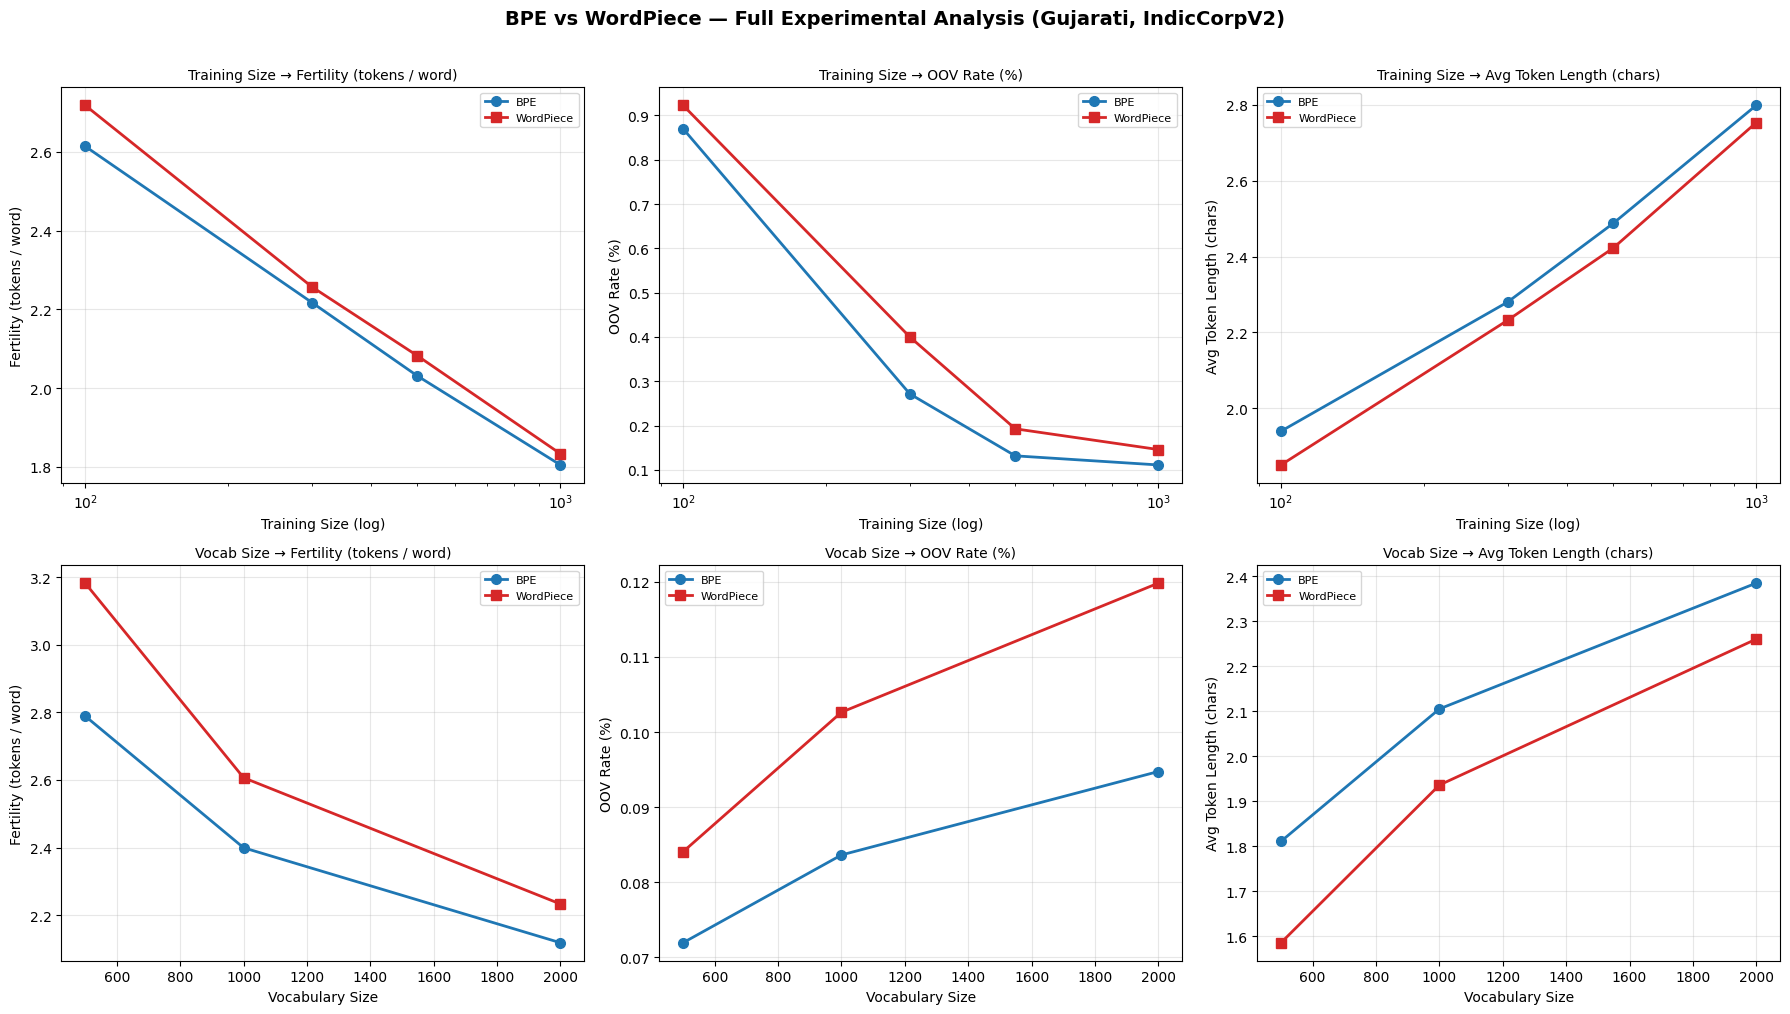

Full analysis figure saved.


In [18]:
# ─── Final: Save a comparison plot ────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

titles_A = [f"[Size] {m}" for _, m in metrics_to_plot]
titles_B = [f"[Vocab] {m}" for _, m in metrics_to_plot]

for col, (metric_key, metric_label) in enumerate(metrics_to_plot):
    # Top row: size experiment
    ax = axes[0, col]
    for algo in ["BPE", "WordPiece"]:
        xs = [r["train_size"] for r in results_by_size[algo]]
        ys = [r[metric_key]   for r in results_by_size[algo]]
        ax.plot(xs, ys, marker=markers[algo], color=colors[algo], linewidth=2, markersize=7, label=algo)
    ax.set_title(f"Training Size → {metric_label}", fontsize=10)
    ax.set_xscale("log")
    ax.set_xlabel("Training Size (log)")
    ax.set_ylabel(metric_label)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # Bottom row: vocab experiment
    ax = axes[1, col]
    for algo in ["BPE", "WordPiece"]:
        xs = [r["vocab_size"] for r in results_by_vocab[algo]]
        ys = [r[metric_key]   for r in results_by_vocab[algo]]
        ax.plot(xs, ys, marker=markers[algo], color=colors[algo], linewidth=2, markersize=7, label=algo)
    ax.set_title(f"Vocab Size → {metric_label}", fontsize=10)
    ax.set_xlabel("Vocabulary Size")
    ax.set_ylabel(metric_label)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("BPE vs WordPiece — Full Experimental Analysis (Gujarati, IndicCorpV2)",
             fontsize=14, y=1.01, fontweight='bold')
plt.tight_layout()
plt.savefig("full_analysis.png", dpi=130, bbox_inches='tight')
plt.show()
print("Full analysis figure saved.")

---

## Appendix — How to Run with the Full IndicCorpV2 Dataset

```python
from datasets import load_dataset
import indicnlp.tokenize.sentence_tokenize as isent

# 1. Download the dataset
ds = load_dataset(
    "ai4bharat/IndicCorpV2",
    data_files={"train": "data/guj/*.jsonl.gz"},
    split="train"
)

# 2. Sentence tokenize (Gujarati code = 'gu')
all_sentences = []
for row in ds:
    sents = isent.sentence_split(row['text'], lang='gu')
    all_sentences.extend(sents)

print(f"Total sentences: {len(all_sentences):,}")

# 3. Then call length_stratified_split with DEV_SIZE=1000, TEST_SIZE=1000
# 4. Then train BPE / WordPiece with TRAIN_SIZES and VOCAB_SIZES
```

Install indicnlp with:
```bash
pip install indic-nlp-library
```

---
*Assignment 3 — ILLM Lab | Language: Gujarati (guj_Gujr) | Tokenizers: BPE, WordPiece*